In [1]:
import copy
import gc
import os
import sys
import time
import traceback

import numpy as np
import matplotlib.pyplot as plt

home_dir = os.path.expanduser('~')
oft_root_path = os.path.join(home_dir, 'OpenFUSIONToolkit/install_release')
os.environ['OFT_ROOTPATH'] = oft_root_path
sys.path.append(os.path.join(oft_root_path, 'python'))

BASE_DIR = os.path.abspath('.')

from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import gs_Domain, save_gs_mesh, load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import read_eqdsk, eval_green
from helper_fct import resize_polygon, update_boundary, make_3x3_thick
from opt_comp_combined_boundary import boundary_distance

In [2]:
REG_IN = 1e-6
RFIL = 0.01

eqdsk = read_eqdsk(os.path.join(BASE_DIR, 'examples/data/eqdsk/DIIID_opt_3coil_symm'))
LCFS_contour = eqdsk['rzout'].copy()
fixed_LCFS = LCFS_contour
fixed_mag_axis = np.array([1.77764093, -0.04014656])
lim = update_boundary(r0=1.69, z0=0, a0=0.67, kappa=2, delta=0.8, squar=0.15, npts=1700)

tmp_dir = os.path.join(BASE_DIR, 'tmp', 'fb_candidate_cost')
os.makedirs(tmp_dir, exist_ok=True)
os.chdir(tmp_dir)

mesh_dx = 0.015
gs_mesh = gs_Domain()
gs_mesh.define_region('plasma', mesh_dx, 'plasma')
gs_mesh.add_polygon(LCFS_contour, 'plasma')
mesh_pts, mesh_lc, mesh_reg = gs_mesh.build_mesh()

myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)
mygs.setup_mesh(mesh_pts, mesh_lc)
mygs.settings.free_boundary = False
F0 = eqdsk['rcentr'] * eqdsk['bcentr']
mygs.setup(order=2, F0=F0)
mygs.set_targets(Ip=eqdsk['ip'], pax=eqdsk['pres'][0])
mygs.init_psi()
mygs.solve()

r_bnd, psi_bnd = mygs.get_vfixed()
print(f'boundary points: {len(r_bnd)}')

os.chdir(BASE_DIR)

Assembling regions:
  # of unique points    = 282
  # of unique segments  = 3
Generating mesh with Triangle:
  # of points  = 9105
  # of cells   = 17925
  # of regions = 1
#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:   main
Revision id:          e2083e8
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Fortran input file    = /var/folders/z5/d2ytmy3d2h18qcqwb9v71w2m0000gq/T/oft_48831/oftpyin
XML input file        = none
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.301E+00
    # of points  =    9105
    # of edges   =   27029
    # of cells   =   17925
    # of boundary points =     283
    # of boundary edges  =     283
    #

In [3]:
from opt_comp_combined_boundary import make_mesh, boundary_distance

TRUE_COILS_TOP = np.array([
    [2.6127, 0.4377],
    [2.3744, 1.1156],
    [1.6883, 1.5868],
])

def fixed_boundary_cost_rz(coil_locs_top, r_bnd, psi_bnd, rfil, reg_in):
    coil_centers_3x3 = []
    for loc in coil_locs_top:
        coil_centers_3x3.append(make_3x3_thick(loc.tolist(), rfil))
        coil_centers_3x3.append(make_3x3_thick([loc[0], -loc[1]], rfil))
    n_bnd = psi_bnd.shape[0]
    n_coils_total = len(coil_centers_3x3)
    con = np.zeros((n_bnd - 1 + n_coils_total, n_coils_total))
    for i, filament_set in enumerate(coil_centers_3x3):
        flux_tmp = np.zeros(n_bnd)
        for fil in filament_set:
            flux_tmp += eval_green(r_bnd, fil)
        con[:n_bnd - 1, i] = flux_tmp[1:] - flux_tmp[0]
        con[n_bnd - 1 + i, i] = reg_in
    err = np.zeros(n_bnd - 1 + n_coils_total)
    err[:n_bnd - 1] = psi_bnd[1:] - psi_bnd[0]
    currs, residuals, _, _ = np.linalg.lstsq(con, err, rcond=None)
    fixed_cost = residuals[0] if len(residuals) > 0 else np.linalg.norm(con @ currs - err) ** 2
    return fixed_cost, currs


def free_boundary_solve_rz(coil_locs_top, myOFT, eqdsk, fixed_mag_axis, fixed_LCFS, lim, weight_fb, xpoint_index=55):
    """Returns (fb_cost, mygs2, free_lcfs). Caller must del mygs2."""
    pid = os.getpid()
    mesh_file = os.path.join(BASE_DIR, 'tmp', f'mesh_true_{pid}.h5')
    eqdsk_tmp = os.path.join(BASE_DIR, 'tmp', f'gTRUE_{pid}')
    dx, dy = 0.03, 0.03
    scan_geom = {'coils': {}}
    for i, loc in enumerate(coil_locs_top):
        pts_top = np.array([[loc[0]-dx, loc[1]+dy], [loc[0]+dx, loc[1]+dy],
                            [loc[0]+dx, loc[1]-dy], [loc[0]-dx, loc[1]-dy]])
        scan_geom['coils'][f'F{i}A'] = {'pts': copy.deepcopy(pts_top), 'nturns': 1.0}
        scan_geom['coils'][f'F{i}B'] = {'pts': copy.deepcopy(pts_top * np.array([1, -1])), 'nturns': 1.0}
    try:
        os.chdir(os.path.join(BASE_DIR, 'tmp'))
        make_mesh(scan_geom, mesh_file, lim)
        mygs2 = TokaMaker(myOFT)
        mesh_pts2, mesh_lc2, mesh_reg2, coil_dict2, cond_dict2 = load_gs_mesh(mesh_file)
        mygs2.setup_mesh(mesh_pts2, mesh_lc2, mesh_reg2)
        mygs2.setup_regions(cond_dict=cond_dict2, coil_dict=coil_dict2)
        mygs2.settings.free_boundary = True
        mygs2.setup(order=2, F0=eqdsk['rcentr'] * eqdsk['bcentr'])
        mygs2.set_targets(Ip=eqdsk['ip'], R0=float(fixed_mag_axis[0]), V0=float(fixed_mag_axis[1]))
        mygs2.set_coil_bounds({key: [-6e8, 6e8] for key in mygs2.coil_sets})
        isoflux_pts = eqdsk['rzout'].copy()
        w_iso = np.ones(len(isoflux_pts[:, 0]))
        w_iso[xpoint_index] = 1e4
        mygs2.set_isoflux(isoflux_pts, weights=w_iso)
        reg_terms = [mygs2.coil_reg_term({name: 1.0}, target=0.0, weight=weight_fb) for name in mygs2.coil_sets]
        mygs2.set_coil_reg(reg_terms=reg_terms)
        mygs2.init_psi(r0=1.8, z0=-0.040, a=0.45, kappa=1.547, delta=-0.288)
        mygs2.solve()
        mygs2.save_eqdsk(eqdsk_tmp, truncate_eq=False)
        EQ_out = read_eqdsk(eqdsk_tmp)
        fb_cost = boundary_distance(fixed_LCFS, EQ_out['rzout'], fixed_mag_axis)
        return fb_cost, mygs2, EQ_out['rzout']
    except Exception:
        traceback.print_exc()
        return 1e6, None, None
    finally:
        os.chdir(BASE_DIR)
        for f in [mesh_file, eqdsk_tmp]:
            if os.path.exists(f): os.remove(f)

Assembling regions:
  # of unique points    = 940
  # of unique segments  = 31
Generating mesh with Triangle:
  # of points  = 10442
  # of cells   = 20530
  # of regions = 10

**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.231E+01
    # of points  =   10442
    # of edges   =   30971
    # of cells   =   20530
    # of boundary points =     352
    # of boundary edges  =     352
    # of boundary cells  =     352
  Resolution statistics:
    hmin =  9.177E-03
    hrms =  3.939E-02
    hmax =  1.200E-01
  Surface grounded at vertex     892


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    1.8242000000000001E-002
Starting non-linear GS solver
     1 -1.4448E-01  2.1169E-01  3.1345E-03  1.8134E+00 -5.3488E-02 -0.0000E+00
     2  1.5962E-01  1.6317E-01  8.5064E-04  1.8079E+00 -5.5964E-02 -0.0000E+00
     3  3.26

Assembling regions:
  # of unique points    = 940
  # of unique segments  = 31
Generating mesh with Triangle:
  # of points  = 10442
  # of cells   = 20530
  # of regions = 10

**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.231E+01
    # of points  =   10442
    # of edges   =   30971
    # of cells   =   20530
    # of boundary points =     352
    # of boundary edges  =     352
    # of boundary cells  =     352
  Resolution statistics:
    hmin =  9.177E-03
    hrms =  3.939E-02
    hmax =  1.200E-01
  Surface grounded at vertex     892


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    1.6293999999999999E-002


Starting non-linear GS solver
     1 -1.2863E-01  2.1435E-01  3.4583E-03  1.8126E+00 -5.1697E-02 -0.0000E+00
     2  1.8587E-01  1.6563E-01  8.3477E-04  1.8069E+00 -5.3896E-02 -0.0000E+00
     3  3.4948E-01  1.3988E-01  6.4843E-04  1.7995E+00 -5.5427E-02 -0.0000E+00
     4  4.4997E-01  1.2385E-01  4.8129E-04  1.7936E+00 -5.6370E-02 -0.0000E+00
     5  5.2527E-01  1.1166E-01  3.6198E-04  1.7890E+00 -5.6967E-02 -0.0000E+00
     6  5.9161E-01  1.0080E-01  3.0058E-04  1.7850E+00 -5.7269E-02 -0.0000E+00
     7  6.5477E-01  9.0380E-02  2.7322E-04  1.7813E+00 -5.7521E-02 -0.0000E+00
     8  6.7615E-01  8.6948E-02  1.4750E-04  1.7792E+00 -5.7670E-02 -0.0000E+00
     9  6.8335E-01  8.5843E-02  6.7671E-05  1.7783E+00 -5.7747E-02 -0.0000E+00
    10  6.8573E-01  8.5501E-02  2.8598E-05  1.7779E+00 -5.7783E-02 -0.0000E+00
    11  6.8651E-01  8.5402E-02  1.1496E-05  1.7777E+00 -5.7799E-02 -0.0000E+00
    12  6.8676E-01  8.5376E-02  4.4778E-06  1.7777E+00 -5.7806E-02 -0.0000E+00
    13  6.8683E-01  8.

Starting non-linear GS solver
     1 -1.2844E-01  2.1438E-01  3.4624E-03  1.8126E+00 -5.1677E-02 -0.0000E+00
     2  1.8615E-01  1.6566E-01  8.3464E-04  1.8069E+00 -5.3872E-02 -0.0000E+00
     3  3.4974E-01  1.3992E-01  6.4896E-04  1.7995E+00 -5.5401E-02 -0.0000E+00
     4  4.5020E-01  1.2389E-01  4.8154E-04  1.7936E+00 -5.6344E-02 -0.0000E+00
     5  5.2549E-01  1.1171E-01  3.6214E-04  1.7890E+00 -5.6940E-02 -0.0000E+00
     6  5.9184E-01  1.0084E-01  3.0083E-04  1.7850E+00 -5.7242E-02 -0.0000E+00
     7  6.5502E-01  9.0417E-02  2.7346E-04  1.7813E+00 -5.7494E-02 -0.0000E+00
     8  6.7639E-01  8.6986E-02  1.4761E-04  1.7792E+00 -5.7643E-02 -0.0000E+00
     9  6.8358E-01  8.5883E-02  6.7701E-05  1.7783E+00 -5.7720E-02 -0.0000E+00
    10  6.8596E-01  8.5541E-02  2.8595E-05  1.7779E+00 -5.7756E-02 -0.0000E+00
    11  6.8674E-01  8.5441E-02  1.1504E-05  1.7777E+00 -5.7772E-02 -0.0000E+00
    12  6.8698E-01  8.5415E-02  4.4879E-06  1.7777E+00 -5.7779E-02 -0.0000E+00
    13  6.8706E-01  8.

Starting non-linear GS solver
     1 -1.2844E-01  2.1438E-01  3.4624E-03  1.8126E+00 -5.1676E-02 -0.0000E+00
     2  1.8615E-01  1.6566E-01  8.3464E-04  1.8069E+00 -5.3872E-02 -0.0000E+00
     3  3.4974E-01  1.3992E-01  6.4897E-04  1.7995E+00 -5.5401E-02 -0.0000E+00
     4  4.5020E-01  1.2389E-01  4.8155E-04  1.7936E+00 -5.6343E-02 -0.0000E+00
     5  5.2549E-01  1.1171E-01  3.6214E-04  1.7890E+00 -5.6940E-02 -0.0000E+00
     6  5.9184E-01  1.0084E-01  3.0083E-04  1.7850E+00 -5.7241E-02 -0.0000E+00
     7  6.5502E-01  9.0418E-02  2.7346E-04  1.7813E+00 -5.7493E-02 -0.0000E+00
     8  6.7639E-01  8.6987E-02  1.4761E-04  1.7792E+00 -5.7643E-02 -0.0000E+00
     9  6.8358E-01  8.5883E-02  6.7702E-05  1.7783E+00 -5.7719E-02 -0.0000E+00
    10  6.8596E-01  8.5541E-02  2.8595E-05  1.7779E+00 -5.7756E-02 -0.0000E+00
    11  6.8674E-01  8.5442E-02  1.1504E-05  1.7777E+00 -5.7772E-02 -0.0000E+00
    12  6.8699E-01  8.5416E-02  4.4881E-06  1.7777E+00 -5.7779E-02 -0.0000E+00
    13  6.8706E-01  8.

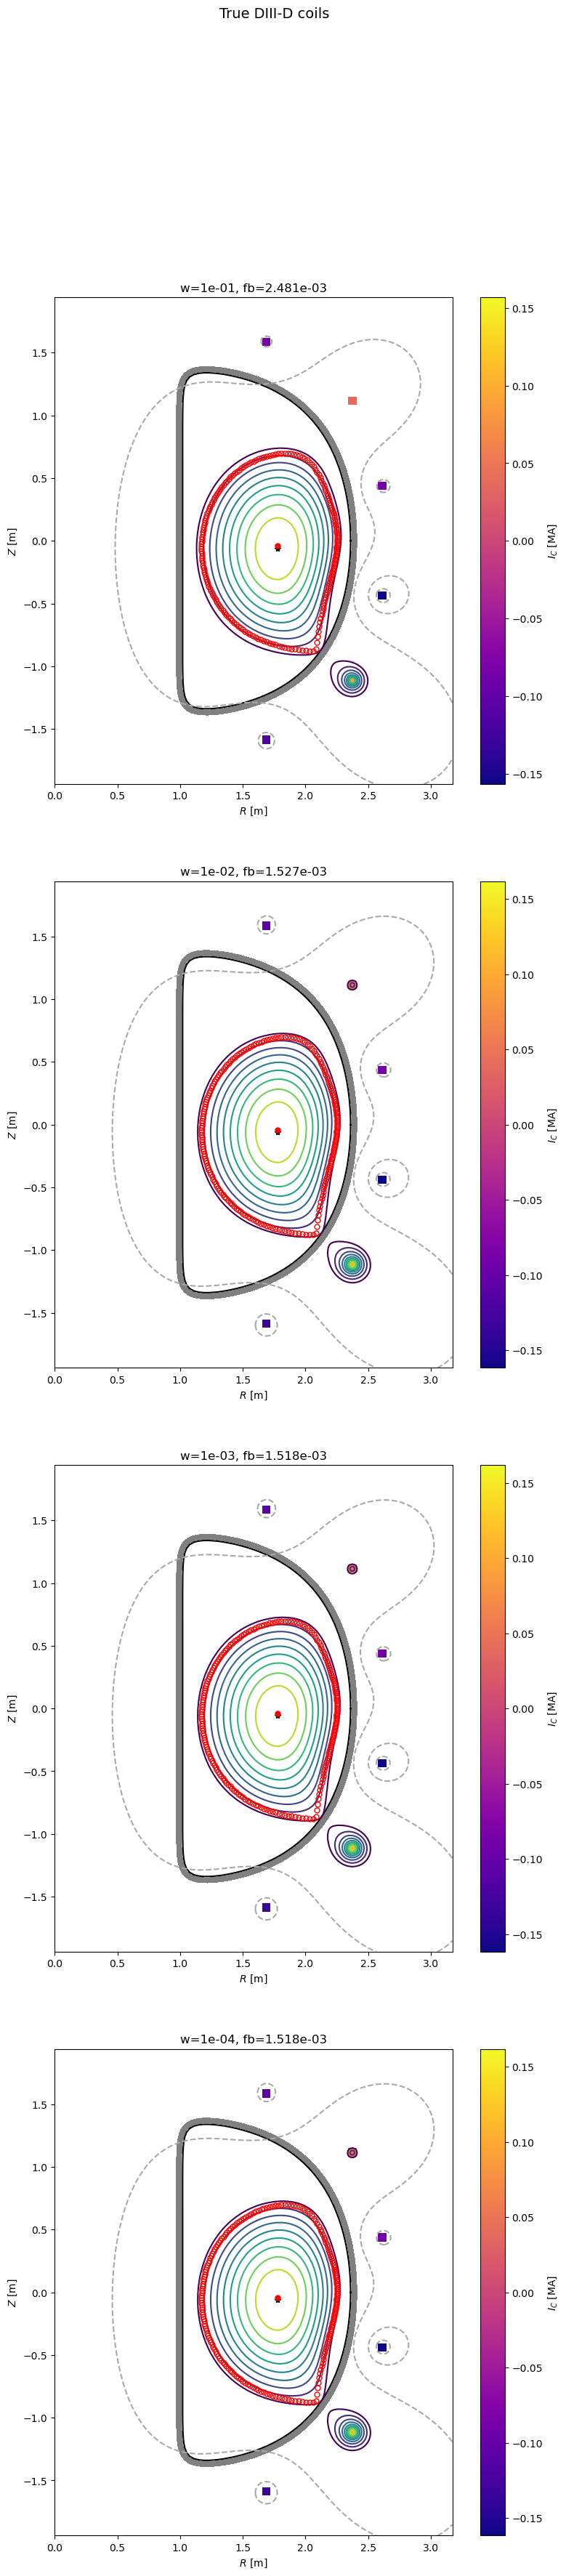

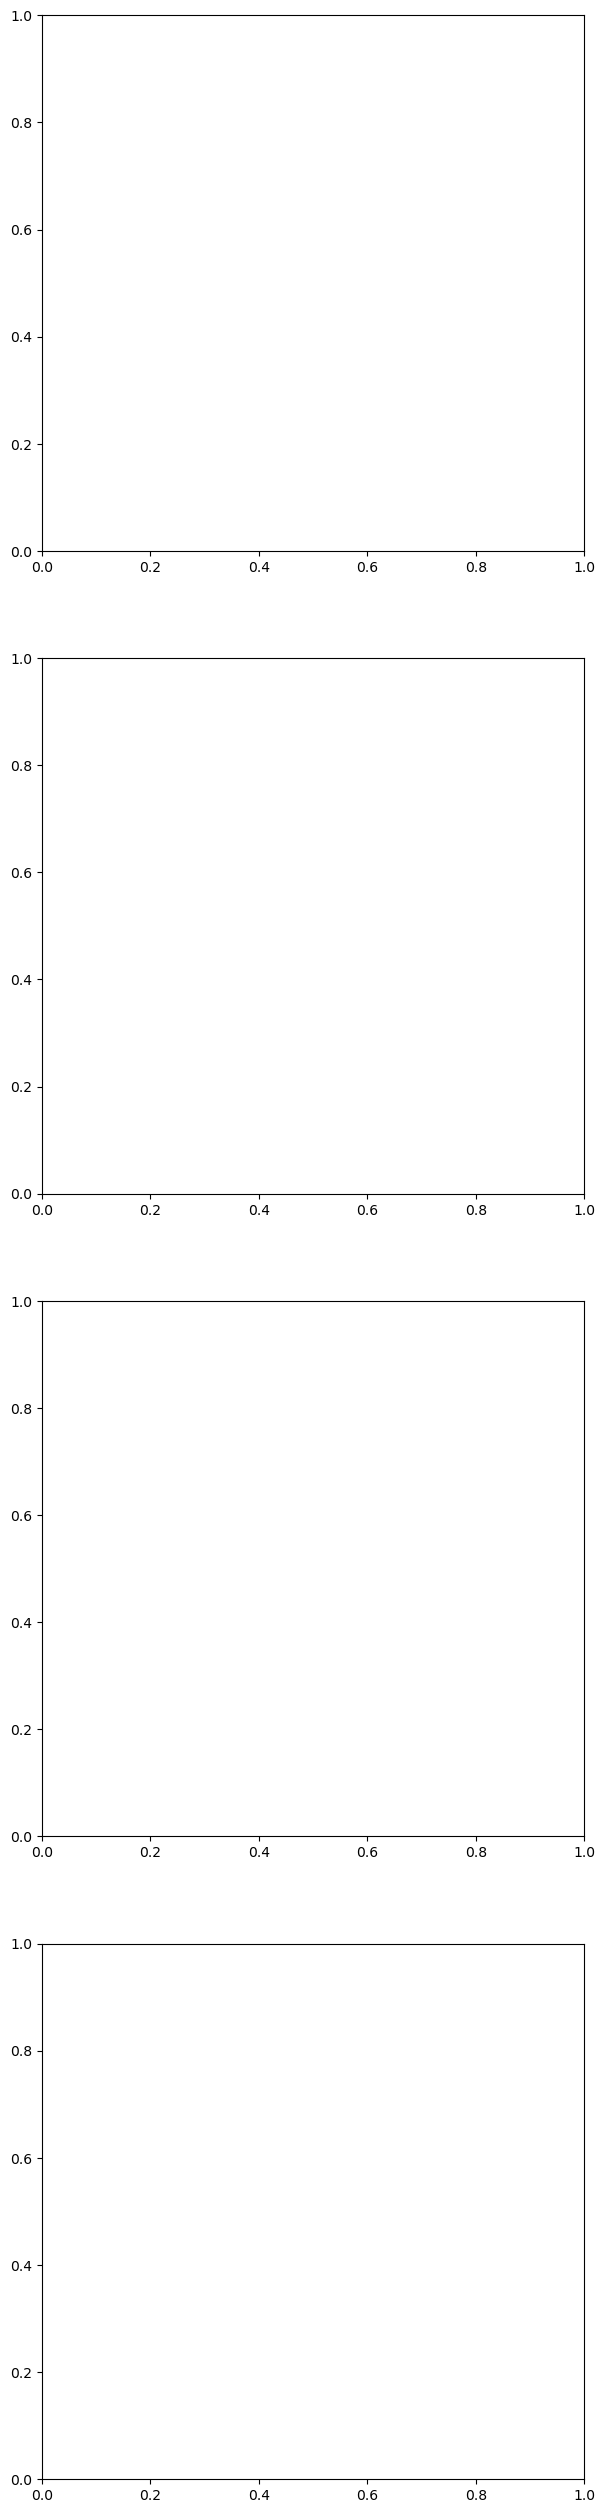

saved true_coil_machine_all.png
saved true_coil_lcfs_all.png


In [4]:
WEIGHTS = [1e-1, 1e-2, 1e-3, 1e-4]
results = []
fig_all, axes_all = plt.subplots(4, 1, figsize=(10, 40))
fig_lcfs, axes_lcfs = plt.subplots(4, 1, figsize=(7, 32))

for i, w in enumerate(WEIGHTS):
    t0 = time.time()
    fb_cost_w, mygs2, free_lcfs_w = free_boundary_solve_rz(
        TRUE_COILS_TOP, myOFT, eqdsk, fixed_mag_axis, fixed_LCFS, lim, w)
    print(f'weight={w:.0e}  fb_cost={fb_cost_w:.6e}  ({time.time()-t0:.1f}s)')
    results.append((w, fb_cost_w, free_lcfs_w))

    ax_c = axes_all.flat[i]
    if mygs2 is not None:
        mygs2.plot_machine(fig_all, ax_c, coil_colormap='plasma', coil_symmap=True,
                           coil_scale=1e-6, coil_clabel=r'$I_C$ [MA]', vacuum_color=None)
        mygs2.plot_psi(fig_all, ax_c, xpoint_color=None, plasma_nlevels=10, vacuum_nlevels=4)
        del mygs2; gc.collect()

    ax_c.plot(fixed_LCFS[:, 0], fixed_LCFS[:, 1], 'ro', fillstyle='none', markersize=5)
    ax_c.plot(fixed_mag_axis[0], fixed_mag_axis[1], 'ro', markersize=5)
    ax_c.set_title(f'w={w:.0e}, fb={fb_cost_w:.3e}')
    ax_c.set_xlabel(r'$R$ [m]')
    ax_c.set_ylabel(r'$Z$ [m]')

fig_all.suptitle('True DIII-D coils', fontsize=14)
fig_all.savefig('true_coil_machine_all.png', dpi=130)
plt.show()
print('saved true_coil_machine_all.png')

for i, (w, fb_cost_w, free_lcfs_w) in enumerate(results):
    ax = axes_lcfs.flat[i]
    ax.plot(fixed_LCFS[:, 0], fixed_LCFS[:, 1], 'ro', fillstyle='none', markersize=5, label='target')
    if free_lcfs_w is not None:
        ax.plot(free_lcfs_w[:, 0], free_lcfs_w[:, 1], 'b-', lw=1.5, label='free')
    for R, Z in TRUE_COILS_TOP:
        ax.add_patch(plt.Rectangle((R - 0.035, Z - 0.035), 0.07, 0.07,
                                   facecolor='none', edgecolor='red', lw=2))
        ax.add_patch(plt.Rectangle((R - 0.035, -Z - 0.035), 0.07, 0.07,
                                   facecolor='none', edgecolor='red', lw=2))
    ax.plot(fixed_mag_axis[0], fixed_mag_axis[1], 'ro', markersize=5)
    ax.set_title(f'w={w:.0e}, fb={fb_cost_w:.3e}')
    ax.set_xlabel(r'$R$ [m]')
    ax.set_ylabel(r'$Z$ [m]')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=9, handlelength=1.0)

fig_lcfs.suptitle('True DIII-D coils, LCFS comparison', fontsize=14)
fig_lcfs.savefig('true_coil_lcfs_all.png', dpi=130)
plt.show()
print('saved true_coil_lcfs_all.png')